In [1]:
# ============================================================
# EDA SECTION 1: Import libraries
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from urllib.parse import urlparse
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

target_col = "Political Lean"

CLASS_ORDER = ["Conservative", "Liberal"]

LEAN_PALETTE = {
    "Conservative": "darkorange",
    "Liberal": "steelblue"
}

In [2]:
# ============================================================
# EDA SECTION 2: Load the raw dataset
# ============================================================

df_raw = pd.read_csv("reddit_dr.csv")

print("Raw dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns)

display(df_raw.head())

Raw dataset shape: (12854, 9)

Columns:
Index(['Title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'Text', 'Date Created'],
      dtype='object')


,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,NaN,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,NaN,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,NaN,1.646268e+09


Data types:


Title               object
Political Lean      object
Score                int64
Id                  object
Subreddit           object
URL                 object
Num of Comments      int64
Text                object
Date Created       float64
dtype: object

,missing_count,missing_percent
Text,10426,81.110938
Title,0,0.000000
Political Lean,0,0.000000
Score,0,0.000000
Id,0,0.000000
Subreddit,0,0.000000
URL,0,0.000000
Num of Comments,0,0.000000
Date Created,0,0.000000


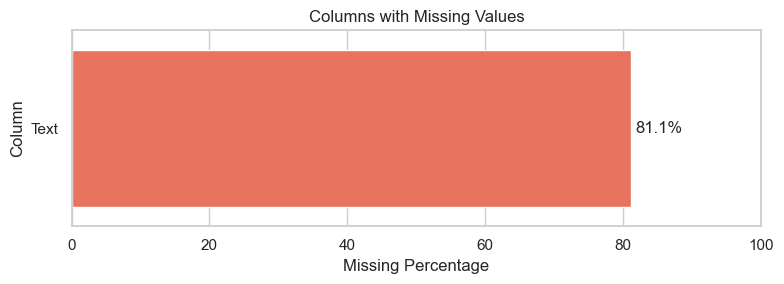

In [3]:
# ============================================================
# EDA SECTION 3: Basic structure and missing values
# ============================================================

print("Data types:")
display(df_raw.dtypes)

missing_df = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_df)

missing_plot = missing_df[missing_df["missing_percent"] > 0].reset_index()

plt.figure(figsize=(8, 3))

ax = sns.barplot(
    data=missing_plot,
    x="missing_percent",
    y="index",
    color="tomato"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Columns with Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

,count,percent
Political Lean,,
Conservative,4535,35.28
Liberal,8319,64.72


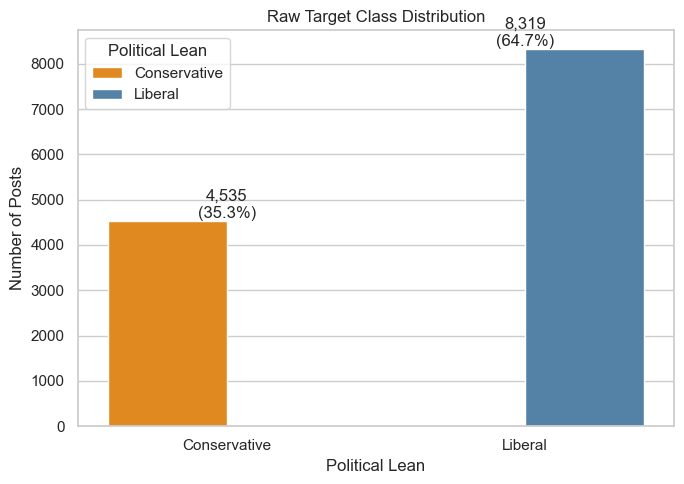

In [5]:
# ============================================================
# EDA SECTION 4: Raw target class distribution
# ============================================================

class_summary = pd.DataFrame({
    "count": df_raw[target_col].value_counts(),
    "percent": df_raw[target_col].value_counts(normalize=True) * 100
}).reindex(CLASS_ORDER)

display(class_summary.round(2))

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=class_summary.reset_index(),
    x=target_col,
    y="count",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
)

for i, row in class_summary.reset_index().iterrows():
    ax.text(
        i,
        row["count"],
        f'{row["count"]:,}\n({row["percent"]:.1f}%)',
        ha="center",
        va="bottom"
    )

plt.title("Raw Target Class Distribution")
plt.xlabel("Political Lean")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

Before removing short or duplicate text: (12854, 13)
After cleaning: (12156, 13)


,Title,Text,combined_text,Political Lean
0,"No matter who someone is, how they look like, ...",,no matter who someone is how they look like wh...,Liberal
1,Biden speech draws 38.2 million U.S. TV viewers,,biden speech draws million u s tv viewers,Liberal
2,State of the union,Who watched the state of the union last night ...,state of the union who watched the state of th...,Liberal
3,We Should Just Give Poor People Money,,we should just give poor people money,Liberal
4,Do it for the Dew,,do it for the dew,Liberal


,count,percent
Political Lean,,
Conservative,4146,34.11
Liberal,8010,65.89


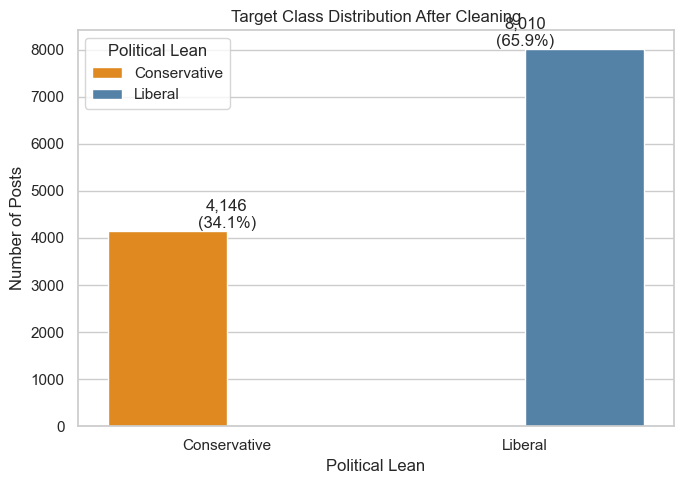

In [7]:
# ============================================================
# EDA SECTION 5: Create cleaned working dataframe
# ============================================================

df = df_raw.copy()

df["Title"] = df["Title"].fillna("")
df["Text"] = df["Text"].fillna("")

df["combined_text_original"] = df["Title"] + " " + df["Text"]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"u/\w+|r/\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["combined_text"] = df["combined_text_original"].apply(clean_text)

df["text_char_length"] = df["combined_text"].str.len()
df["combined_word_count"] = df["combined_text"].apply(lambda x: len(x.split()))

print("Before removing short or duplicate text:", df.shape)

df = df[df["text_char_length"] > 10].copy()
df = df.drop_duplicates(subset=["combined_text"]).copy()

print("After cleaning:", df.shape)

display(df[["Title", "Text", "combined_text", target_col]].head())

clean_class_summary = pd.DataFrame({
    "count": df[target_col].value_counts(),
    "percent": df[target_col].value_counts(normalize=True) * 100
}).reindex(CLASS_ORDER)

display(clean_class_summary.round(2))

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=clean_class_summary.reset_index(),
    x=target_col,
    y="count",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
)

for i, row in clean_class_summary.reset_index().iterrows():
    ax.text(
        i,
        row["count"],
        f'{row["count"]:,}\n({row["percent"]:.1f}%)',
        ha="center",
        va="bottom"
    )

plt.title("Target Class Distribution After Cleaning")
plt.xlabel("Political Lean")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# EDA SECTION 6: Encode the target variable
# ============================================================

le = LabelEncoder()
df["y"] = le.fit_transform(df[target_col])

print("Class mapping:")
for i, label in enumerate(le.classes_):
    print(f"{i} = {label}")

display(df[[target_col, "y"]].head())

Class mapping:
0 = Conservative
1 = Liberal


,Political Lean,y
0,Liberal,1
1,Liberal,1
2,Liberal,1
3,Liberal,1
4,Liberal,1


,has_title,has_body_text
Political Lean,,
Conservative,100.0,23.01
Liberal,100.0,18.04


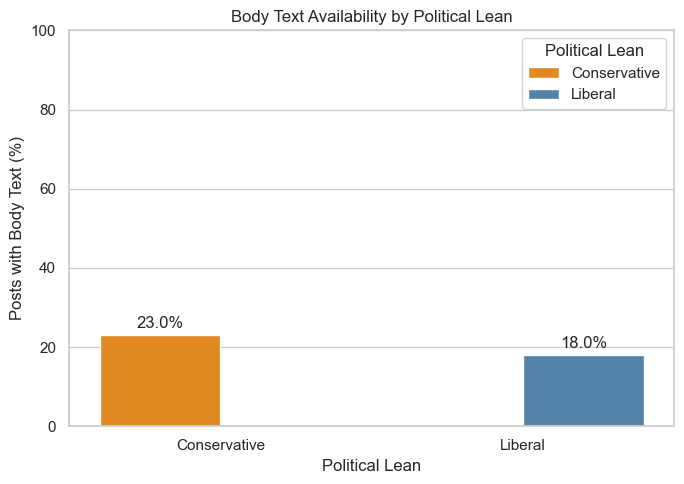

In [10]:
# ============================================================
# EDA SECTION 7: Text availability
# ============================================================

df["has_title"] = df["Title"].str.strip().ne("")
df["has_body_text"] = df["Text"].str.strip().ne("")

text_availability = df.groupby(target_col)[["has_title", "has_body_text"]].mean() * 100

display(text_availability.round(2))

body_text_plot = text_availability["has_body_text"].reindex(CLASS_ORDER).reset_index()
body_text_plot.columns = [target_col, "body_text_available_percent"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=body_text_plot,
    x=target_col,
    y="body_text_available_percent",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Body Text Availability by Political Lean")
plt.xlabel("Political Lean")
plt.ylabel("Posts with Body Text (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

title_word_count        body_word_count         \
                           mean median            mean median   
Political Lean                                                  
Conservative              12.43   11.0           33.04    0.0   
Liberal                   12.98   11.0           38.17    0.0   

               combined_word_count        text_char_length         
                              mean median             mean median  
Political Lean                                                     
Conservative                 46.16   13.0           261.55   77.0  
Liberal                      51.66   13.0           297.03   77.0

Word count plot capped at 99th percentile: 692 words
This cap is only for visualization. The original data is not deleted.


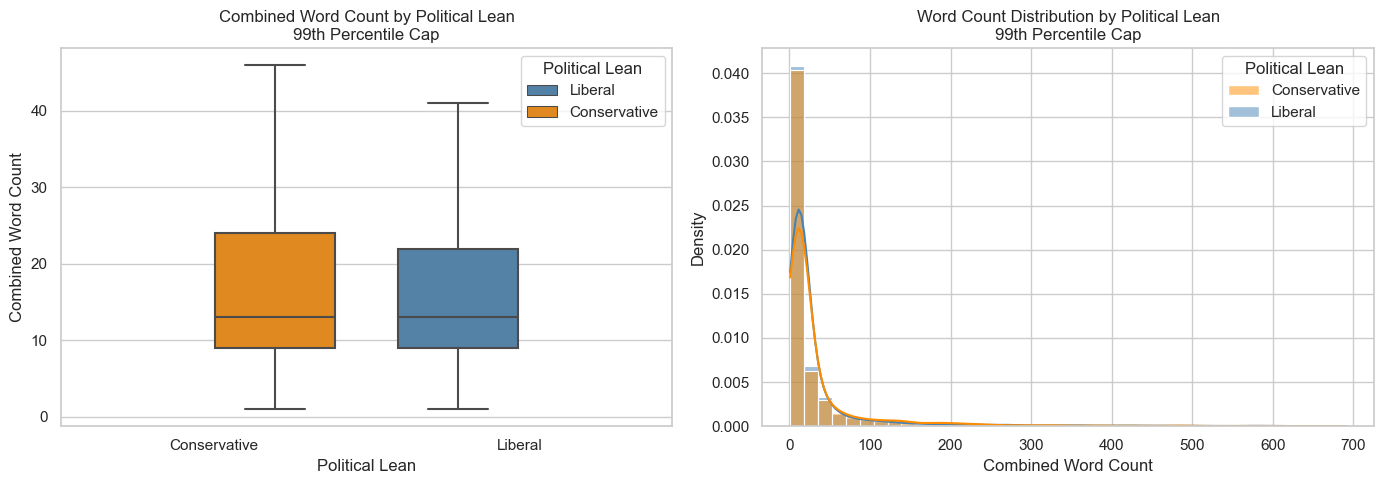

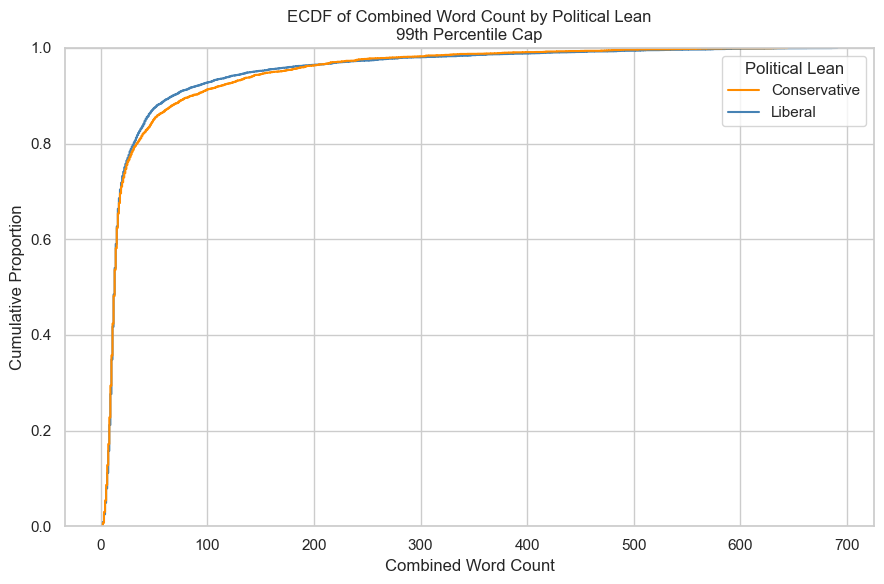

In [11]:
# ============================================================
# EDA SECTION 8: Text length by class
# ============================================================

df["title_word_count"] = df["Title"].apply(lambda x: len(str(x).split()))
df["body_word_count"] = df["Text"].apply(lambda x: len(str(x).split()))
df["combined_word_count"] = df["combined_text"].apply(lambda x: len(x.split()))

length_summary = df.groupby(target_col)[
    ["title_word_count", "body_word_count", "combined_word_count", "text_char_length"]
].agg(["mean", "median"])

display(length_summary.round(2))

word_count_cap = df["combined_word_count"].quantile(0.99)
df_length_plot = df[df["combined_word_count"] <= word_count_cap].copy()

print(f"Word count plot capped at 99th percentile: {word_count_cap:.0f} words")
print("This cap is only for visualization. The original data is not deleted.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_length_plot,
    x=target_col,
    y="combined_word_count",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
    showfliers=False,
    ax=axes[0],
)

axes[0].set_title("Combined Word Count by Political Lean\n99th Percentile Cap")
axes[0].set_xlabel("Political Lean")
axes[0].set_ylabel("Combined Word Count")

sns.histplot(
    data=df_length_plot,
    x="combined_word_count",
    hue=target_col,
    hue_order=CLASS_ORDER,
    bins=40,
    stat="density",
    common_norm=False,
    kde=True,
    palette=LEAN_PALETTE,
    ax=axes[1]
)

axes[1].set_title("Word Count Distribution by Political Lean\n99th Percentile Cap")
axes[1].set_xlabel("Combined Word Count")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

sns.ecdfplot(
    data=df_length_plot,
    x="combined_word_count",
    hue=target_col,
    hue_order=CLASS_ORDER,
    palette=LEAN_PALETTE
)

plt.title("ECDF of Combined Word Count by Political Lean\n99th Percentile Cap")
plt.xlabel("Combined Word Count")
plt.ylabel("Cumulative Proportion")
plt.tight_layout()
plt.show()

Score                Num of Comments                \
                  mean median     std            mean median    std   
Political Lean                                                        
Conservative     40.70    5.0  413.91           27.26    3.0  90.77   
Liberal         157.82   23.0  539.38           15.40    4.0  37.80   

               signed_log_score              log_num_comments               
                           mean median   std             mean median   std  
Political Lean                                                              
Conservative               1.94   1.79  1.56             1.81   1.39  1.56  
Liberal                    3.34   3.18  1.83             1.80   1.61  1.36

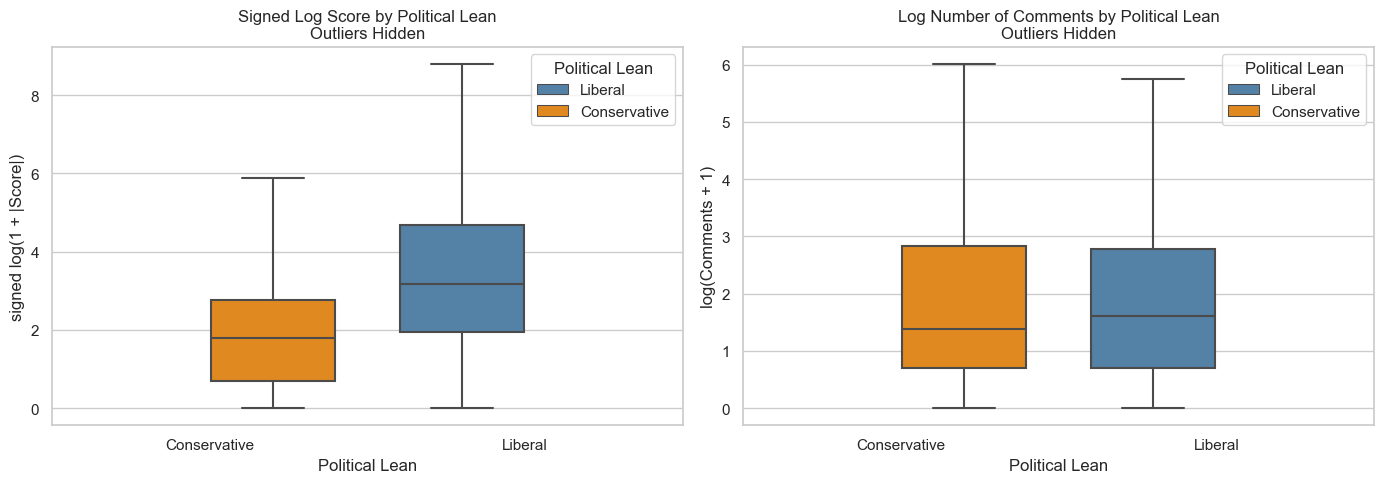

In [13]:
# ============================================================
# EDA SECTION 9: Reddit engagement variables
# ============================================================

df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["Num of Comments"] = pd.to_numeric(df["Num of Comments"], errors="coerce")

def signed_log1p(x):
    if pd.isna(x):
        return np.nan
    return np.sign(x) * np.log1p(abs(x))

df["signed_log_score"] = df["Score"].apply(signed_log1p)
df["log_num_comments"] = np.log1p(df["Num of Comments"].clip(lower=0))

engagement_summary = df.groupby(target_col)[
    ["Score", "Num of Comments", "signed_log_score", "log_num_comments"]
].agg(["mean", "median", "std"])

display(engagement_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x=target_col,
    y="signed_log_score",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
    showfliers=False,
    ax=axes[0],
)

axes[0].set_title("Signed Log Score by Political Lean\nOutliers Hidden")
axes[0].set_xlabel("Political Lean")
axes[0].set_ylabel("signed log(1 + |Score|)")

sns.boxplot(
    data=df,
    x=target_col,
    y="log_num_comments",
    hue=target_col,
    order=CLASS_ORDER,
    palette=LEAN_PALETTE,
    showfliers=False,
    ax=axes[1],
)

axes[1].set_title("Log Number of Comments by Political Lean\nOutliers Hidden")
axes[1].set_xlabel("Political Lean")
axes[1].set_ylabel("log(Comments + 1)")

plt.tight_layout()
plt.show()

Political Lean,Conservative,Liberal
Subreddit,,
Capitalism,954,0
socialism,0,953
SocialDemocracy,0,953
Libertarian,951,0
progressive,0,940
feminisms,0,932
alltheleft,0,925
democrats,0,904
DemocraticSocialism,0,882


Political Lean,Conservative,Liberal
Subreddit,,
Capitalism,1.0,0.0
socialism,0.0,1.0
SocialDemocracy,0.0,1.0
Libertarian,1.0,0.0
progressive,0.0,1.0
feminisms,0.0,1.0
alltheleft,0.0,1.0
democrats,0.0,1.0
DemocraticSocialism,0.0,1.0


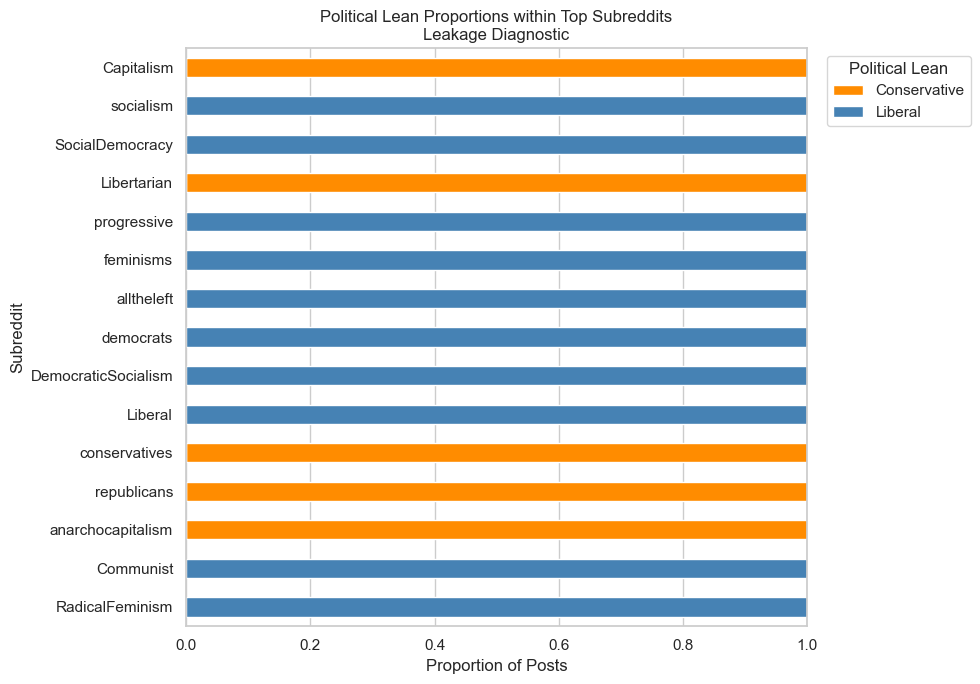

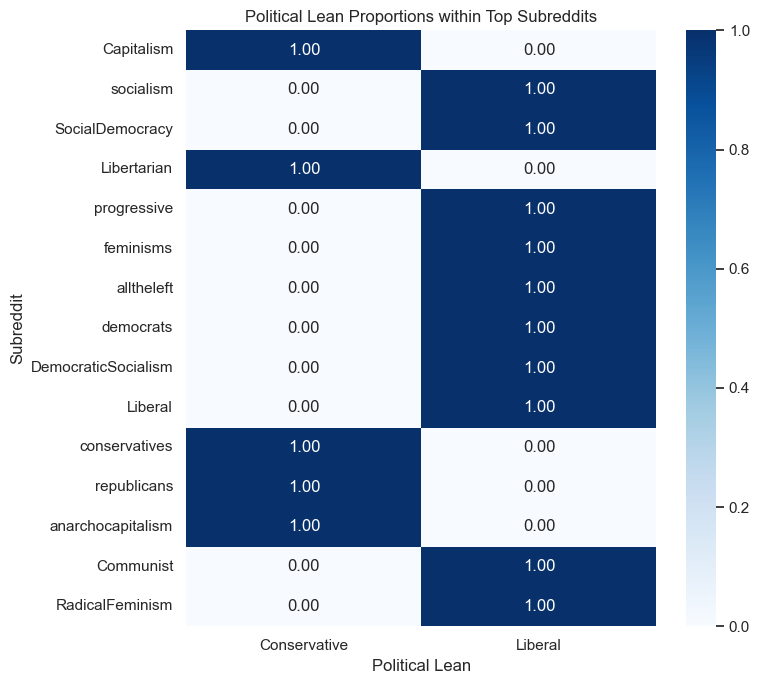

In [14]:
# ============================================================
# EDA SECTION 10: Subreddit composition as leakage diagnostic
# ============================================================

top_subreddits = df["Subreddit"].value_counts().head(15).index
df_top_subs = df[df["Subreddit"].isin(top_subreddits)].copy()

subreddit_counts = pd.crosstab(
    df_top_subs["Subreddit"],
    df_top_subs[target_col]
).reindex(top_subreddits)

subreddit_props = subreddit_counts.div(subreddit_counts.sum(axis=1), axis=0)

display(subreddit_counts)
display(subreddit_props.round(2))

subreddit_props[CLASS_ORDER].plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    color=[LEAN_PALETTE[label] for label in CLASS_ORDER]
)

plt.title("Political Lean Proportions within Top Subreddits\nLeakage Diagnostic")
plt.xlabel("Proportion of Posts")
plt.ylabel("Subreddit")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.legend(title="Political Lean", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))

sns.heatmap(
    subreddit_props[CLASS_ORDER],
    annot=True,
    cmap="Blues",
    fmt=".2f",
    vmin=0,
    vmax=1
)

plt.title("Political Lean Proportions within Top Subreddits")
plt.xlabel("Political Lean")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

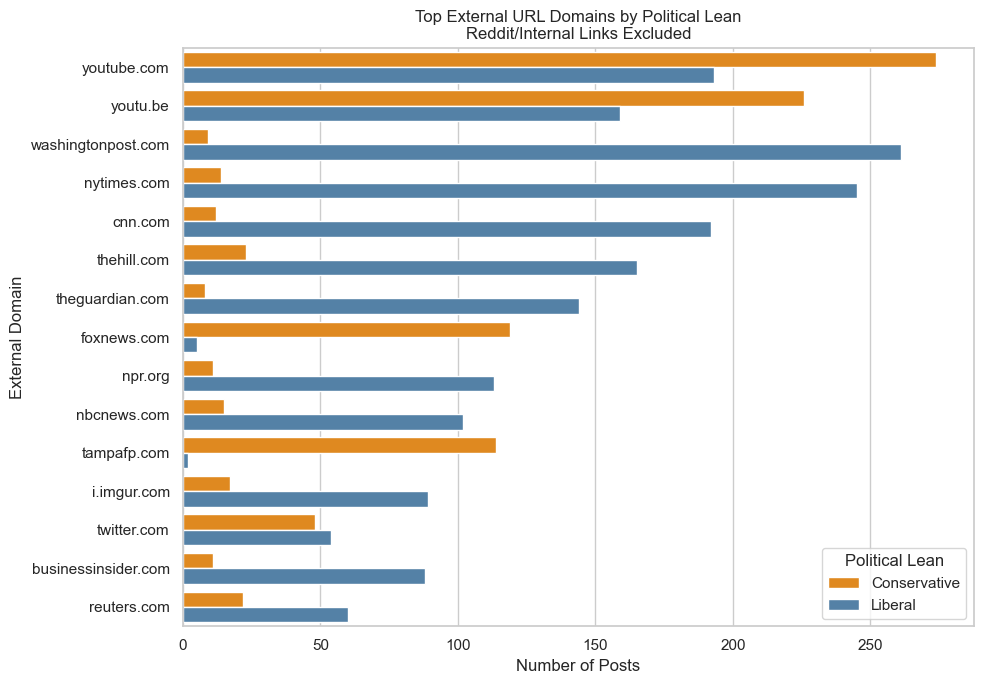

In [15]:
# ============================================================
# EDA SECTION 11: URL domain analysis as leakage diagnostic
# ============================================================

def extract_domain(url):
    try:
        if pd.isna(url):
            return "missing"

        parsed = urlparse(str(url))
        domain = parsed.netloc.lower().replace("www.", "")

        if domain == "":
            return "reddit/internal"

        return domain

    except Exception:
        return "unknown"

df["url_domain"] = df["URL"].apply(extract_domain)

internal_domains = [
    "reddit.com",
    "i.redd.it",
    "v.redd.it",
    "redd.it",
    "reddit/internal"
]

df_external_domains = df[~df["url_domain"].isin(internal_domains)].copy()

top_external_domains = df_external_domains["url_domain"].value_counts().head(15).index

df_top_external_domains = df_external_domains[
    df_external_domains["url_domain"].isin(top_external_domains)
].copy()

plt.figure(figsize=(10, 7))

sns.countplot(
    data=df_top_external_domains,
    y="url_domain",
    hue=target_col,
    hue_order=CLASS_ORDER,
    order=top_external_domains,
    palette=LEAN_PALETTE
)

plt.title("Top External URL Domains by Political Lean\nReddit/Internal Links Excluded")
plt.xlabel("Number of Posts")
plt.ylabel("External Domain")
plt.legend(title="Political Lean")
plt.tight_layout()
plt.show()

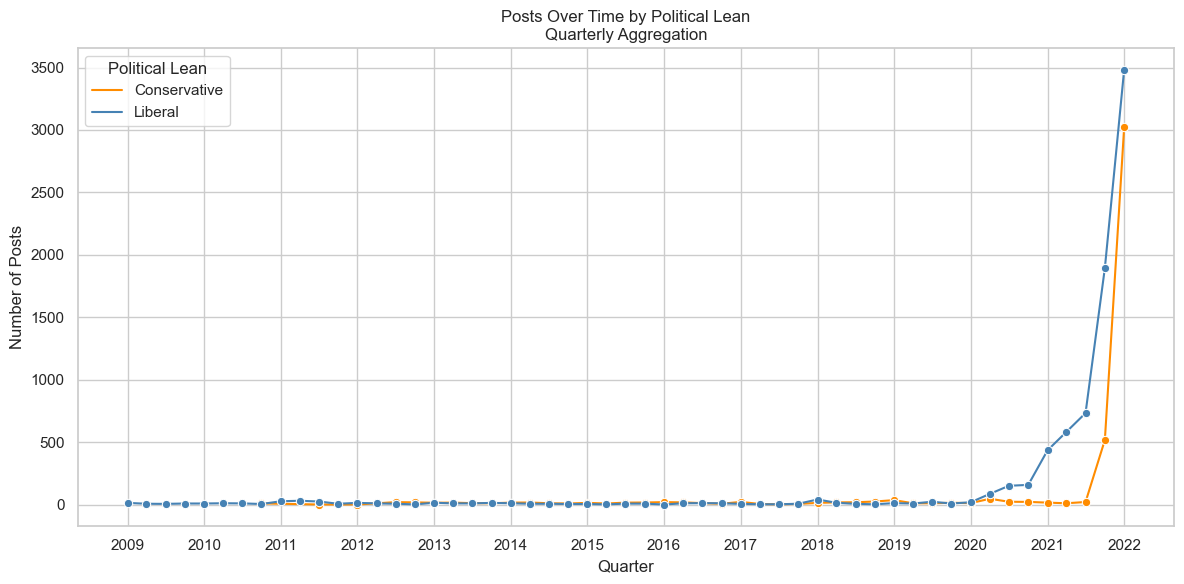

In [16]:
# ============================================================
# EDA SECTION 12: Time trend
# ============================================================

df["Date Created"] = pd.to_numeric(df["Date Created"], errors="coerce")
df["created_datetime"] = pd.to_datetime(df["Date Created"], unit="s", errors="coerce")

df["created_month"] = df["created_datetime"].dt.to_period("M").astype(str)
df["created_quarter"] = df["created_datetime"].dt.to_period("Q").dt.to_timestamp()

quarterly_counts = df.dropna(subset=["created_datetime"]).groupby(
    ["created_quarter", target_col]
).size().reset_index(name="count")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=quarterly_counts,
    x="created_quarter",
    y="count",
    hue=target_col,
    hue_order=CLASS_ORDER,
    palette=LEAN_PALETTE,
    marker="o"
)

plt.title("Posts Over Time by Political Lean\nQuarterly Aggregation")
plt.xlabel("Quarter")
plt.ylabel("Number of Posts")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

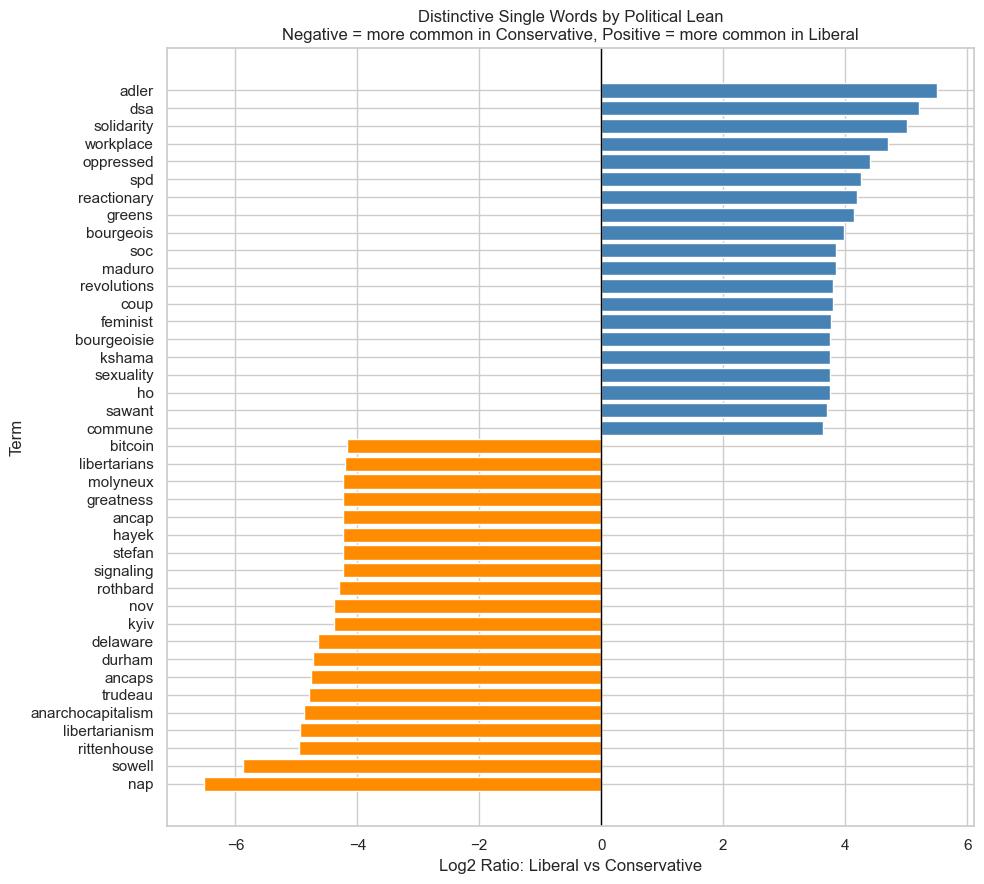

,term,count_Conservative,count_Liberal,total_count,log2_ratio,log_total_count,more_common_in
4319,nap,43,0,43,-6.519406,1.643453,Conservative
6153,sowell,27,0,27,-5.867329,1.447158,Conservative
5673,rittenhouse,88,5,93,-4.950745,1.973128,Conservative
3793,libertarianism,43,2,45,-4.934443,1.662758,Conservative
278,anarchocapitalism,13,0,13,-4.867329,1.146128,Conservative
6802,trudeau,79,5,84,-4.796940,1.929419,Conservative
282,ancaps,25,1,26,-4.760414,1.431364,Conservative
2032,durham,37,2,39,-4.722939,1.602060,Conservative
1678,delaware,11,0,11,-4.644937,1.079181,Conservative
3649,kyiv,19,1,20,-4.381902,1.322219,Conservative


In [17]:
# ============================================================
# EDA SECTION 13: Distinctive single words
# ============================================================

def compute_term_association(
    data,
    text_col,
    label_col,
    ngram_range=(1, 1),
    min_df=5,
    smoothing=1
):
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
    )

    X_counts = vectorizer.fit_transform(data[text_col])
    terms = np.array(vectorizer.get_feature_names_out())

    class_names = sorted(data[label_col].dropna().unique())

    if len(class_names) != 2:
        raise ValueError("This function expects exactly two classes.")

    class_0, class_1 = class_names

    labels = data[label_col].values

    counts_0 = np.asarray(X_counts[labels == class_0].sum(axis=0)).ravel()
    counts_1 = np.asarray(X_counts[labels == class_1].sum(axis=0)).ravel()

    rate_0 = (counts_0 + smoothing) / (counts_0.sum() + smoothing * len(counts_0))
    rate_1 = (counts_1 + smoothing) / (counts_1.sum() + smoothing * len(counts_1))

    log2_ratio = np.log2(rate_1 / rate_0)
    total_count = counts_0 + counts_1

    term_stats = pd.DataFrame({
        "term": terms,
        f"count_{class_0}": counts_0,
        f"count_{class_1}": counts_1,
        "total_count": total_count,
        "log2_ratio": log2_ratio,
        "log_total_count": np.log10(total_count + 1),
        "more_common_in": np.where(log2_ratio < 0, class_0, class_1)
    })

    return term_stats, class_0, class_1


def plot_distinctive_terms(
    data,
    text_col,
    label_col,
    ngram_range=(1, 1),
    top_n=20,
    min_df=5,
    title="Distinctive Terms by Political Lean"
):
    term_stats, class_0, class_1 = compute_term_association(
        data=data,
        text_col=text_col,
        label_col=label_col,
        ngram_range=ngram_range,
        min_df=min_df
    )

    top_class_0 = term_stats.sort_values("log2_ratio").head(top_n)
    top_class_1 = term_stats.sort_values("log2_ratio").tail(top_n)

    plot_terms = pd.concat([top_class_0, top_class_1]).sort_values("log2_ratio")

    colors = plot_terms["more_common_in"].map(LEAN_PALETTE)

    plt.figure(figsize=(10, 9))

    plt.barh(
        plot_terms["term"],
        plot_terms["log2_ratio"],
        color=colors
    )

    plt.axvline(0, color="black", linewidth=1)

    plt.title(
        f"{title}\n"
        f"Negative = more common in {class_0}, Positive = more common in {class_1}"
    )

    plt.xlabel(f"Log2 Ratio: {class_1} vs {class_0}")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

    return plot_terms, term_stats, class_0, class_1


distinctive_words, word_stats, class_0, class_1 = plot_distinctive_terms(
    data=df,
    text_col="combined_text",
    label_col=target_col,
    ngram_range=(1, 1),
    top_n=20,
    min_df=5,
    title="Distinctive Single Words by Political Lean"
)

display(distinctive_words)

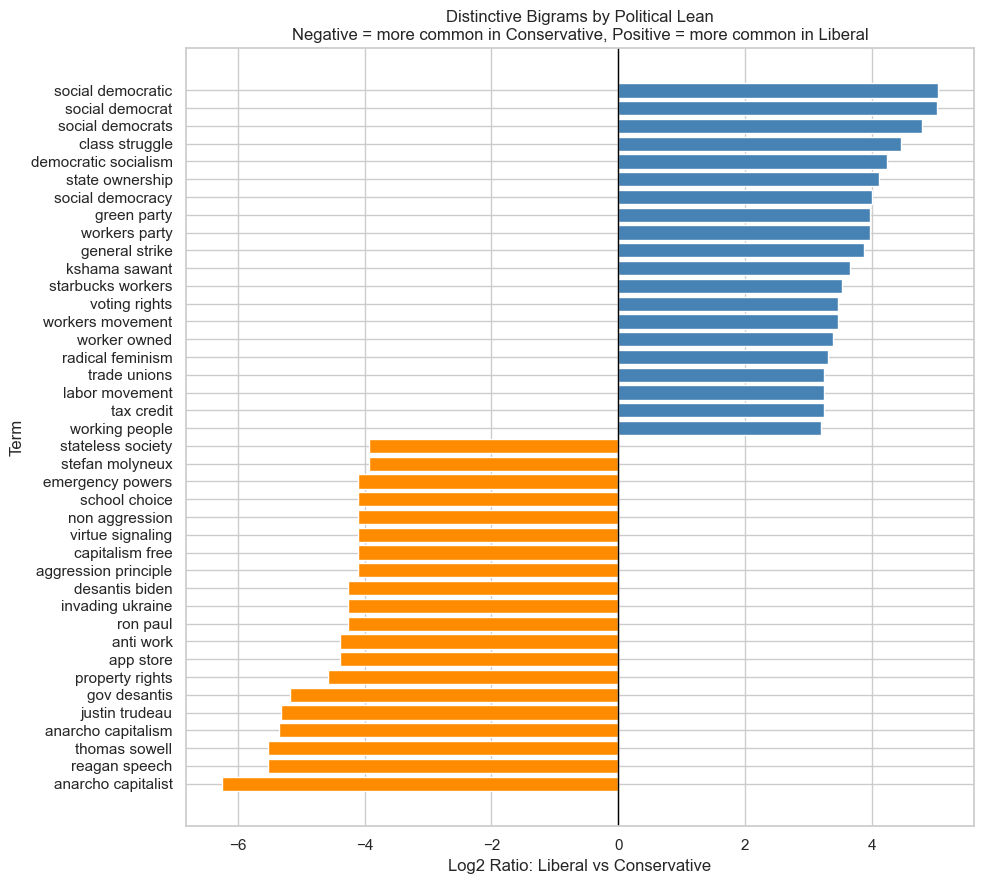

,term,count_Conservative,count_Liberal,total_count,log2_ratio,log_total_count,more_common_in
47,anarcho capitalist,39,0,39,-6.254446,1.602060,Conservative
1439,reagan speech,23,0,23,-5.517480,1.380211,Conservative
1803,thomas sowell,23,0,23,-5.517480,1.380211,Conservative
46,anarcho capitalism,63,2,65,-5.347555,1.819544,Conservative
848,justin trudeau,20,0,20,-5.324835,1.322219,Conservative
655,gov desantis,18,0,18,-5.180445,1.278754,Conservative
1389,property rights,24,1,25,-4.576374,1.414973,Conservative
76,app store,10,0,10,-4.391949,1.041393,Conservative
74,anti work,10,0,10,-4.391949,1.041393,Conservative
1514,ron paul,9,0,9,-4.254446,1.000000,Conservative


In [18]:
# ============================================================
# EDA SECTION 14: Distinctive bigrams
# ============================================================

distinctive_bigrams, bigram_stats, _, _ = plot_distinctive_terms(
    data=df,
    text_col="combined_text",
    label_col=target_col,
    ngram_range=(2, 2),
    top_n=20,
    min_df=5,
    title="Distinctive Bigrams by Political Lean"
)

display(distinctive_bigrams)

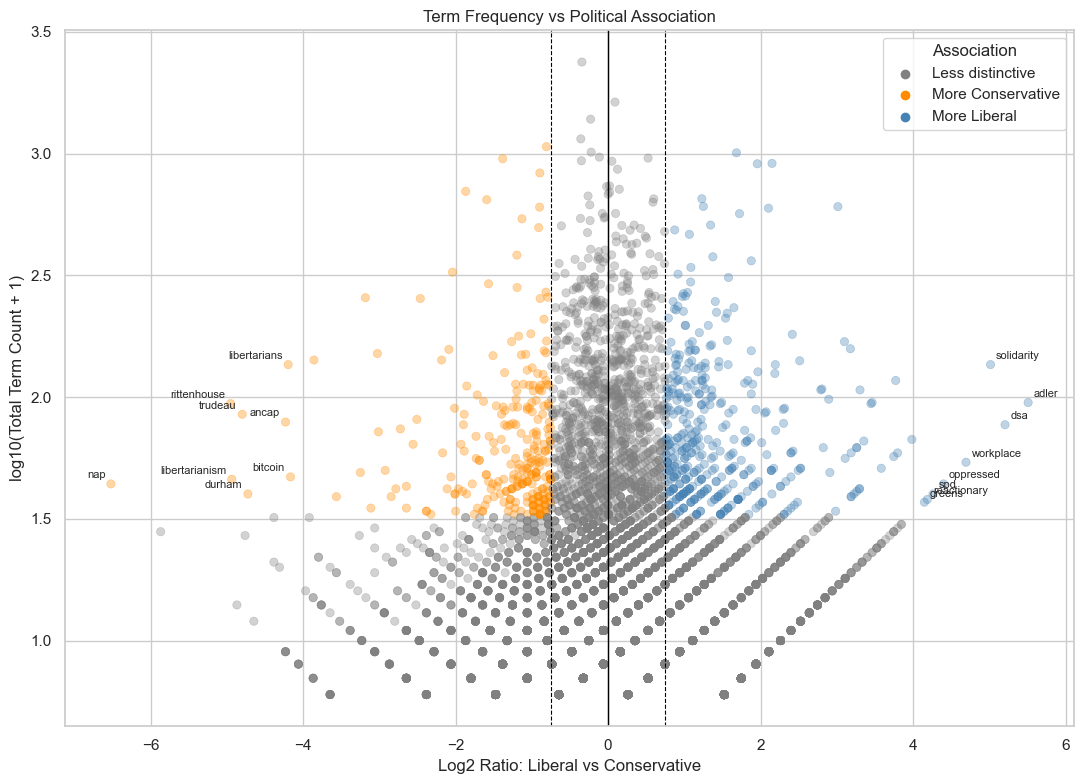

In [19]:
# ============================================================
# EDA SECTION 15: Term frequency vs political association
# ============================================================

term_plot_df = word_stats.copy()

frequency_cutoff = term_plot_df["total_count"].quantile(0.75)
association_cutoff = 0.75

term_plot_df["association_group"] = "Less distinctive"

term_plot_df.loc[
    (term_plot_df["log2_ratio"] <= -association_cutoff) &
    (term_plot_df["total_count"] >= frequency_cutoff),
    "association_group"
] = f"More {class_0}"

term_plot_df.loc[
    (term_plot_df["log2_ratio"] >= association_cutoff) &
    (term_plot_df["total_count"] >= frequency_cutoff),
    "association_group"
] = f"More {class_1}"

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=term_plot_df,
    x="log2_ratio",
    y="log_total_count",
    hue="association_group",
    palette={
        "Less distinctive": "gray",
        f"More {class_0}": LEAN_PALETTE[class_0],
        f"More {class_1}": LEAN_PALETTE[class_1]
    },
    alpha=0.35,
    edgecolor=None
)

label_candidates = term_plot_df[
    (term_plot_df["total_count"] >= frequency_cutoff) &
    (term_plot_df["log2_ratio"].abs() >= association_cutoff)
].copy()

left_labels = label_candidates.sort_values("log2_ratio").head(8)
right_labels = label_candidates.sort_values("log2_ratio").tail(8)

label_terms = pd.concat([left_labels, right_labels]).drop_duplicates("term")

for _, row in label_terms.iterrows():
    ha = "right" if row["log2_ratio"] < 0 else "left"

    plt.annotate(
        row["term"],
        xy=(row["log2_ratio"], row["log_total_count"]),
        xytext=(-4 if row["log2_ratio"] < 0 else 4, 4),
        textcoords="offset points",
        fontsize=8,
        ha=ha
    )

plt.axvline(0, color="black", linewidth=1)
plt.axvline(-association_cutoff, color="black", linestyle="--", linewidth=0.8)
plt.axvline(association_cutoff, color="black", linestyle="--", linewidth=0.8)

plt.title("Term Frequency vs Political Association")
plt.xlabel(f"Log2 Ratio: {class_1} vs {class_0}")
plt.ylabel("log10(Total Term Count + 1)")
plt.legend(title="Association")
plt.tight_layout()
plt.show()

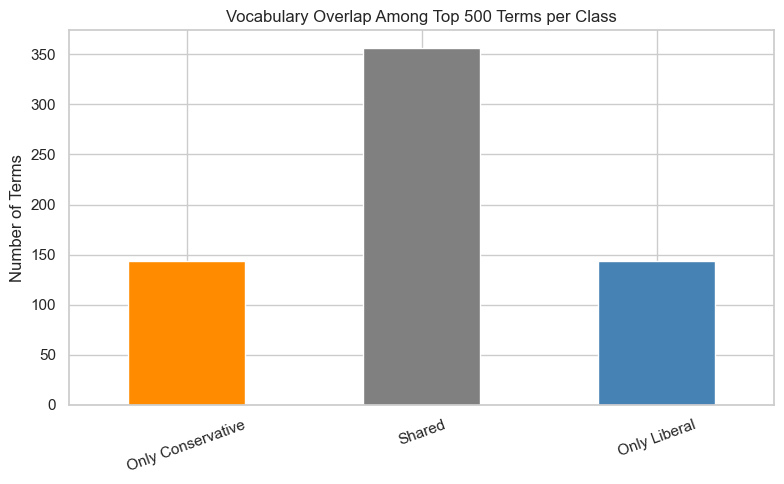

Shared vocabulary percentage among top terms: 71.2 %


In [20]:
# ============================================================
# EDA SECTION 16: Vocabulary overlap
# ============================================================

def get_top_vocab(data, label, top_n=500):
    text = data.loc[data[target_col] == label, "combined_text"]

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=3,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
    )

    X = vectorizer.fit_transform(text)

    terms = np.array(vectorizer.get_feature_names_out())
    counts = np.asarray(X.sum(axis=0)).ravel()

    top_terms = terms[np.argsort(counts)[-top_n:]]

    return set(top_terms)

class_0, class_1 = sorted(df[target_col].dropna().unique())

vocab_0 = get_top_vocab(df, class_0, top_n=500)
vocab_1 = get_top_vocab(df, class_1, top_n=500)

shared_vocab = vocab_0.intersection(vocab_1)
only_0 = vocab_0 - vocab_1
only_1 = vocab_1 - vocab_0

overlap_counts = pd.Series({
    f"Only {class_0}": len(only_0),
    "Shared": len(shared_vocab),
    f"Only {class_1}": len(only_1)
})

plt.figure(figsize=(8, 5))

overlap_counts.plot(
    kind="bar",
    color=[LEAN_PALETTE[class_0], "gray", LEAN_PALETTE[class_1]]
)

plt.title("Vocabulary Overlap Among Top 500 Terms per Class")
plt.ylabel("Number of Terms")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

overlap_denominator = min(len(vocab_0), len(vocab_1))
shared_percentage = len(shared_vocab) / overlap_denominator * 100

print(
    "Shared vocabulary percentage among top terms:",
    round(shared_percentage, 2),
    "%"
)

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
0,people,trump,ukraine,biden,capitalism,social
1,like,donald trump,russia,joe,anarcho,democracy
2,just,donald,war,joe biden,anarcho capitalism,party
3,don,election,putin,president,socialism,social democracy
4,think,gop,russian,court,market,democratic
5,government,says,invasion,supreme court,capitalist,democrats
6,right,president,russia ukraine,supreme,communism,socialism
7,know,house,nato,putin,crisis,socialist
8,want,jan,crisis,president biden,free market,communist
9,women,new,invasion ukraine,administration,free,social democratic


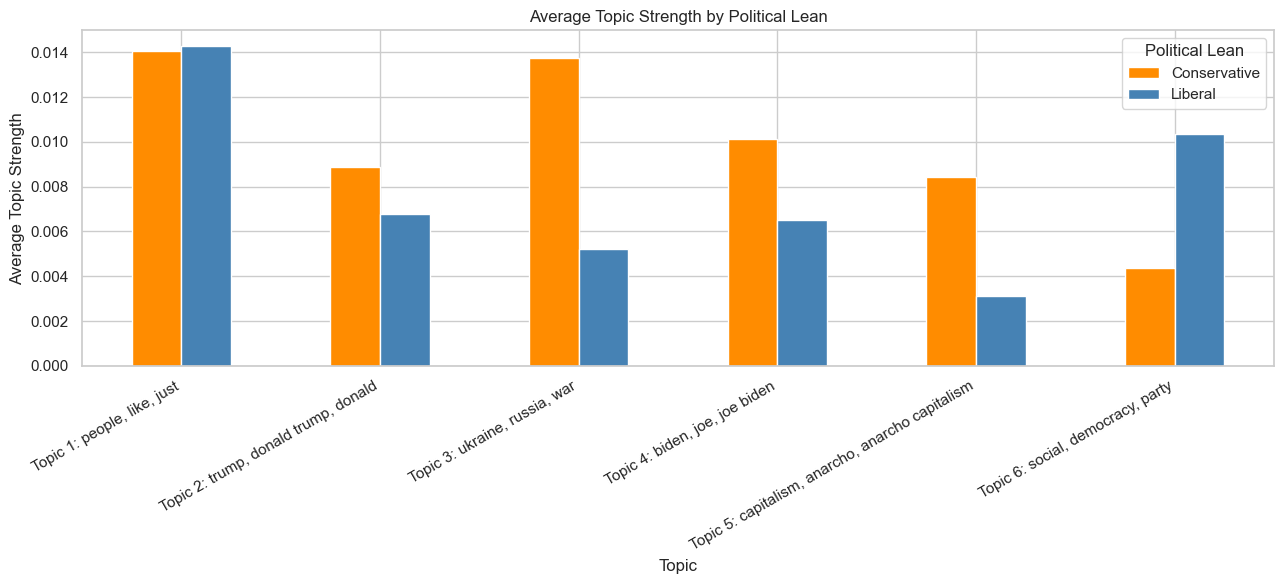

In [21]:
# ============================================================
# EDA SECTION 17: Topic modeling with NMF
# ============================================================

topic_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    max_features=10000
)

X_topic = topic_vectorizer.fit_transform(df["combined_text"])

n_topics = 6

nmf = NMF(
    n_components=n_topics,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=500
)

topic_matrix = nmf.fit_transform(X_topic)
topic_terms = np.array(topic_vectorizer.get_feature_names_out())

def display_topics(model, feature_names, n_top_words=10):
    topics = {}

    for topic_idx, topic in enumerate(model.components_):
        top_terms = feature_names[topic.argsort()[-n_top_words:][::-1]]
        topics[f"Topic {topic_idx + 1}"] = top_terms

    return pd.DataFrame(topics)

topics_df = display_topics(nmf, topic_terms, n_top_words=10)

display(topics_df)

for i in range(n_topics):
    df[f"topic_{i + 1}"] = topic_matrix[:, i]

topic_cols = [f"topic_{i + 1}" for i in range(n_topics)]

topic_summary = df.groupby(target_col)[topic_cols].mean()

topic_labels = {}

for i in range(n_topics):
    top_words = topic_terms[nmf.components_[i].argsort()[-3:][::-1]]
    topic_labels[f"topic_{i + 1}"] = f"Topic {i + 1}: " + ", ".join(top_words)

topic_summary_labeled = topic_summary.rename(columns=topic_labels)

topic_summary_labeled.T.plot(
    kind="bar",
    figsize=(13, 6),
    color=[LEAN_PALETTE[label] for label in topic_summary_labeled.index]
)

plt.title("Average Topic Strength by Political Lean")
plt.xlabel("Topic")
plt.ylabel("Average Topic Strength")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Political Lean")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# EDA SECTION 18: Save the EDA-ready dataset
# ============================================================

final_eda_cols = [
    "Title",
    "Text",
    "combined_text",
    "combined_text_original",
    target_col,
    "y",
    "Score",
    "Num of Comments",
    "signed_log_score",
    "log_num_comments",
    "Subreddit",
    "URL",
    "url_domain",
    "Date Created",
    "created_datetime",
    "created_month",
    "created_quarter",
    "title_word_count",
    "body_word_count",
    "combined_word_count",
    "text_char_length",
]

eda_ready_df = df[final_eda_cols].copy()

print("EDA-ready dataset shape:", eda_ready_df.shape)

display(eda_ready_df.head())

eda_ready_df.to_csv("reddit_eda_ready.csv", index=False)

print("Saved file: reddit_eda_ready.csv")

EDA-ready dataset shape: (12156, 21)


,Title,Text,combined_text,combined_text_original,Political Lean,y,Score,Num of Comments,signed_log_score,log_num_comments,...,URL,url_domain,Date Created,created_datetime,created_month,created_quarter,title_word_count,body_word_count,combined_word_count,text_char_length
0,"No matter who someone is, how they look like, ...",,no matter who someone is how they look like wh...,"No matter who someone is, how they look like, ...",Liberal,1,1,0,0.693147,0.000000,...,https://v.redd.it/ng5fyl7hp2l81,v.redd.it,1.646272e+09,2022-03-03 01:42:57,2022-03,2022-01-01,35,0,35,196
1,Biden speech draws 38.2 million U.S. TV viewers,,biden speech draws million u s tv viewers,Biden speech draws 38.2 million U.S. TV viewers,Liberal,1,6,1,1.945910,0.693147,...,https://www.reuters.com/world/us/biden-speech-...,reuters.com,1.646271e+09,2022-03-03 01:31:48,2022-03,2022-01-01,8,0,8,41
2,State of the union,Who watched the state of the union last night ...,state of the union who watched the state of th...,State of the union Who watched the state of th...,Liberal,1,1,1,0.693147,0.693147,...,https://www.reddit.com/r/DemocraticSocialism/c...,reddit.com,1.646270e+09,2022-03-03 01:21:28,2022-03,2022-01-01,4,14,18,90
3,We Should Just Give Poor People Money,,we should just give poor people money,We Should Just Give Poor People Money,Liberal,1,7,3,2.079442,1.386294,...,https://youtu.be/a80kRjpubG0,youtu.be,1.646270e+09,2022-03-03 01:05:08,2022-03,2022-01-01,7,0,7,37
4,Do it for the Dew,,do it for the dew,Do it for the Dew,Liberal,1,6,1,1.945910,0.693147,...,https://i.redd.it/drmunn90f2l81.jpg,i.redd.it,1.646268e+09,2022-03-03 00:43:03,2022-03,2022-01-01,5,0,5,17


Saved file: reddit_eda_ready.csv


In [24]:
# ============================================================
# EDA SECTION 19: Final EDA summary
# ============================================================

print("EDA SUMMARY")
print("=" * 60)

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Cleaned EDA dataset shape: {eda_ready_df.shape}")

print()
print("Target variable:")
print(f"- {target_col}")

print()
print("Class mapping:")
for i, label in enumerate(le.classes_):
    print(f"- {i} = {label}")

print()
print("Main text feature prepared:")
print("- combined_text = cleaned Title + Text")

print()
print("EDA graphs created:")
print("- missing values bar chart")
print("- raw target class distribution")
print("- cleaned target class distribution")
print("- body text availability chart")
print("- capped word count boxplot, histogram, and ECDF")
print("- engagement boxplots with log transformations")
print("- subreddit composition leakage diagnostic")
print("- external URL domain leakage diagnostic")
print("- quarterly time trend")
print("- distinctive single words")
print("- distinctive bigrams")
print("- term frequency vs political association plot")
print("- vocabulary overlap chart")
print("- topic modeling topic chart")

print()
print("Saved cleaned feature file:")
print("- reddit_eda_ready.csv")

print()
print("Important modeling warning:")
print("- Subreddit and URL/domain variables are useful for EDA, but they may leak the political label.")
print("- The main classifier should mainly use text features unless leakage is explicitly discussed.")

EDA SUMMARY
Raw dataset shape: (12854, 9)
Cleaned EDA dataset shape: (12156, 21)

Target variable:
- Political Lean

Class mapping:
- 0 = Conservative
- 1 = Liberal

Main text feature prepared:
- combined_text = cleaned Title + Text

EDA graphs created:
- missing values bar chart
- raw target class distribution
- cleaned target class distribution
- body text availability chart
- capped word count boxplot, histogram, and ECDF
- engagement boxplots with log transformations
- subreddit composition leakage diagnostic
- external URL domain leakage diagnostic
- quarterly time trend
- distinctive single words
- distinctive bigrams
- term frequency vs political association plot
- vocabulary overlap chart
- topic modeling topic chart

Saved cleaned feature file:
- reddit_eda_ready.csv

Important modeling warning:
- Subreddit and URL/domain variables are useful for EDA, but they may leak the political label.
- The main classifier should mainly use text features unless leakage is explicitly discu